<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
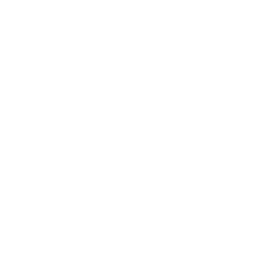
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Hedonic Property Valuation with Stepwise Selection</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Real Estate / Appraisal Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook builds a **hedonic pricing model** for residential property
using `PROC REG`. Hedonic models decompose a sale price into the marginal
contributions of individual property characteristics — square footage,
bedrooms, lot size, age, location — which is exactly what an appraiser or a
portfolio analyst needs for automated valuation.

The workflow has three stages:

1. **Variable selection.** `SELECTION=STEPWISE` screens ten candidate
   structural and locational predictors and keeps only those that earn their
   place statistically.
2. **Final model & multicollinearity.** The selected predictors are refit
   with `VIF` to confirm the coefficients are stable and interpretable.
3. **Influence diagnostics.** Cook's D and leverage from the `OUTPUT`
   statement flag individual sales whose unusual feature combinations move
   the fit — the properties an appraiser should review before trusting the
   model's valuation.

The data step generates **20,000 synthetic sales** from a transparent linear
price formula plus Gaussian noise, so the regression has a known signal to
recover. Every number quoted in the narrative below is taken directly from
the executed output.


## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| `WORK.PROPERTY_SALES` | Synthetic residential sales with structural and locational attributes | 20,000 |

The synthetic generator builds sale price from a transparent linear formula
plus Gaussian noise, so the regression has a known signal to recover. Each
record carries living area, bedrooms, bathrooms, age, lot acreage, garage
spaces, a pool indicator, distance to transit, a school rating, and a crime
index, tagged to one of three metro markets.


---


In [1]:
/* Emit compact PNG graphics for all plots in this notebook */
ods graphics on / outputfmt=png;

/* --------------------------------------------------------
   Generate synthetic residential property sales
   across three metro areas
   -------------------------------------------------------- */
data work.property_sales;
    call streaminit(42);
    array metro_list[3] $15 _temporary_ ('METRO_EAST' 'METRO_CENTRAL' 'METRO_WEST');
    array base_prices[3] _temporary_ (320000 275000 410000);
    do i = 1 to 20000;
        metro_idx = int(rand('uniform') * 3) + 1;
        metro_area = metro_list[metro_idx];
        base_price = base_prices[metro_idx];
        /* Structural features */
        sqft = int(rand('normal', 1850, 550));
        if sqft < 600 then sqft = 600;
        bedrooms = int(rand('normal', 3.2, 0.9));
        if bedrooms < 1 then bedrooms = 1;
        if bedrooms > 6 then bedrooms = 6;
        bathrooms = max(1, int(bedrooms * 0.7 + rand('uniform')));
        year_built = int(rand('normal', 1988, 18));
        if year_built < 1920 then year_built = 1920;
        if year_built > 2025 then year_built = 2025;
        age_years = 2026 - year_built;
        lot_acres = round(rand('exponential') * 0.3 + 0.08, 0.01);
        if lot_acres > 5 then lot_acres = 5;
        garage_spaces = int(rand('uniform') * 3.5);
        has_pool = (rand('uniform') > 0.82);
        /* Locational features */
        dist_transit_mi = round(rand('exponential') * 2.5 + 0.1, 0.1);
        if dist_transit_mi > 20 then dist_transit_mi = 20;
        school_rating = int(rand('normal', 6.5, 1.8));
        if school_rating < 1 then school_rating = 1;
        if school_rating > 10 then school_rating = 10;
        crime_index = round(rand('normal', 45, 18), 1);
        if crime_index < 1 then crime_index = 1;
        if crime_index > 100 then crime_index = 100;
        /* Sale price driven by features */
        sale_price = round(
            base_price
            + 135 * sqft
            + 12000 * bedrooms
            + 18000 * bathrooms
            - 1200 * age_years
            + 45000 * lot_acres
            + 8000 * garage_spaces
            + 25000 * has_pool
            - 6000 * dist_transit_mi
            + 9500 * school_rating
            - 350 * crime_index
            + rand('normal', 0, 35000), 1);
        if sale_price < 50000 then sale_price = 50000;
        output;
    end;
    drop i metro_idx base_price;
run;

proc sort data=work.property_sales;
    by metro_area;
run;

NOTE: ODS Graphics is ON (width=640px, height=480px, format=PNG).
NOTE: DATA work.property_sales


NOTE: Wrote work.property_sales (20000 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.47 seconds
  cpu   0.47 seconds
NOTE: PROC SORT data=work.property_sales

NOTE: Read 20000 rows from work.property_sales.
NOTE: Wrote work.property_sales (20000 rows, 13 columns).
NOTE: PROC SORT statement used.


---


In [2]:
/* --------------------------------------------------------
   Baseline price distribution by metro area
   -------------------------------------------------------- */
proc means data=work.property_sales n mean std min max;
    class metro_area;
    var sale_price sqft age_years dist_transit_mi;
run;

                                                  The MEANS Procedure

                                             Analysis Variable : sale_price

        metro_area             N Obs            Mean        Std Dev         Minimum          Maximum
        --------------------------------------------------------------------------------------------
        METRO_CENTRAL           6593  604250.6541787  92209.4666522  291600.0000000   913342.0000000
        METRO_EAST              6677  647356.8749438  90757.9194694  345394.0000000  1100873.0000000
        METRO_WEST              6730  737581.4511144  92121.2297754  386703.0000000  1068714.0000000
        --------------------------------------------------------------------------------------------

                                                Analysis Variable : sqft

        metro_area             N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.property_sales

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.png


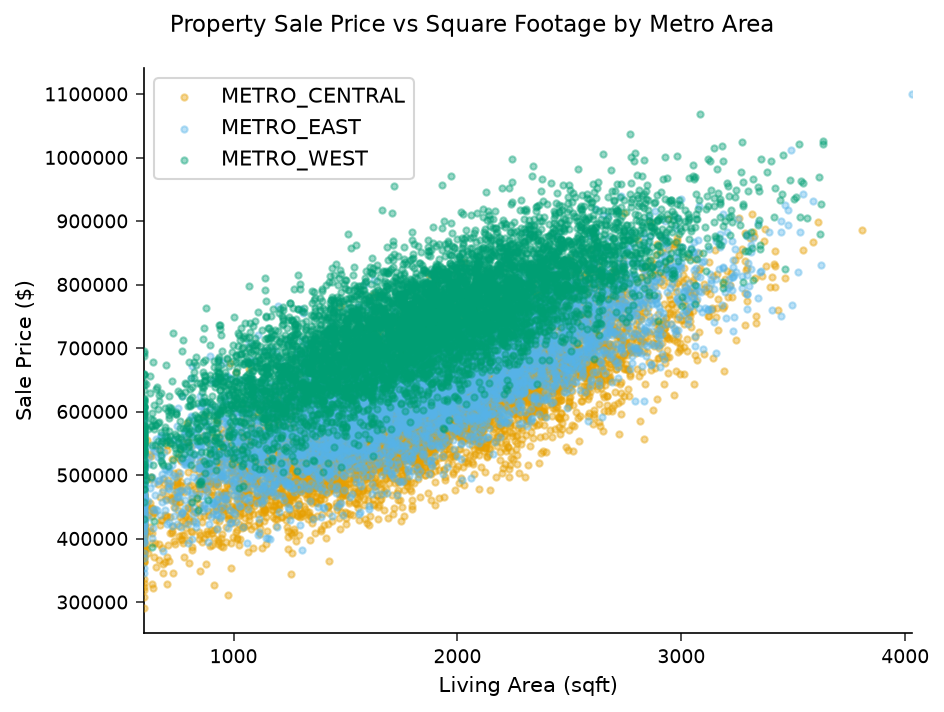

In [3]:
/* --------------------------------------------------------
   Sale price vs square footage by metro area
   -------------------------------------------------------- */
proc sgplot data=work.property_sales;
    scatter x=sqft y=sale_price / group=metro_area
        markerattrs=(symbol=circlefilled size=3) transparency=0.6;
    xaxis label='Living Area (sqft)';
    yaxis label='Sale Price ($)';
    title 'Property Sale Price vs Square Footage by Metro Area';
run;

---


## Stage 1 — Stepwise Variable Selection

Stepwise selection enters and removes candidate predictors one at a time,
keeping a variable only while it clears the entry threshold
(`SLE=0.10`) and dropping it if it later fails the stay threshold
(`SLS=0.10`). This separates the features that genuinely move price from
the ones that ride along with them.


In [4]:
/* --------------------------------------------------------
   Stage 1: stepwise selection over 10 candidate predictors
   -------------------------------------------------------- */
proc reg data=work.property_sales;
    model sale_price = sqft bedrooms bathrooms age_years
                       lot_acres garage_spaces has_pool
                       dist_transit_mi school_rating crime_index
          / selection=stepwise sle=0.10 sls=0.10;
    title 'Stepwise Variable Selection for Sale Price';
run;
quit;


                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                             Dependent Variable: sale_price                                             

Source                 DF         Sum of Squares           Mean Square   F Value    Pr > F
---------------  --------  ---------------------  --------------------  --------  --------
Model                  10  143135643607647.75000  14313564360764.77539   3295.20    <.0001
Error               19989   86827376099367.56250      4343757871.79787                    
Corrected Total     19999  229963019707015.31250                                          

Root MSE       65907.19135    R-Square            0.6224
Dependent Mean  663507.47915    Adj R-Sq            0.6222
Coeff Var          9.93315

                            Paramete

NOTE: PROC REG data=work.property_sales

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: PROC REG ODS Graphics generated.


## Stage 2 — Final Model and Variance Inflation

The variables stepwise retained are refit as the final hedonic model. The
`VIF` option reports a variance inflation factor per predictor; values near
1 confirm a coefficient is not distorted by multicollinearity, so it can be
read as the marginal dollar contribution of its feature. PROC REG also
produces its standard residual-diagnostic panels (residuals vs. predicted,
residual histogram, residuals vs. observation order, Q-Q, and Cook's D),
shown below the model fit.


                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                             Dependent Variable: sale_price                                             

Source                 DF         Sum of Squares           Mean Square   F Value    Pr > F
---------------  --------  ---------------------  --------------------  --------  --------
Model                  10  143135643607647.75000  14313564360764.77539   3295.20    <.0001
Error               19989   86827376099367.56250      4343757871.79787                    
Corrected Total     19999  229963019707015.31250                                          

Root MSE       65907.19135    R-Square            0.6224
Dependent Mean  663507.47915    Adj R-Sq            0.6222
Coeff Var          9.93315

                                    

NOTE: PROC REG data=work.property_sales

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


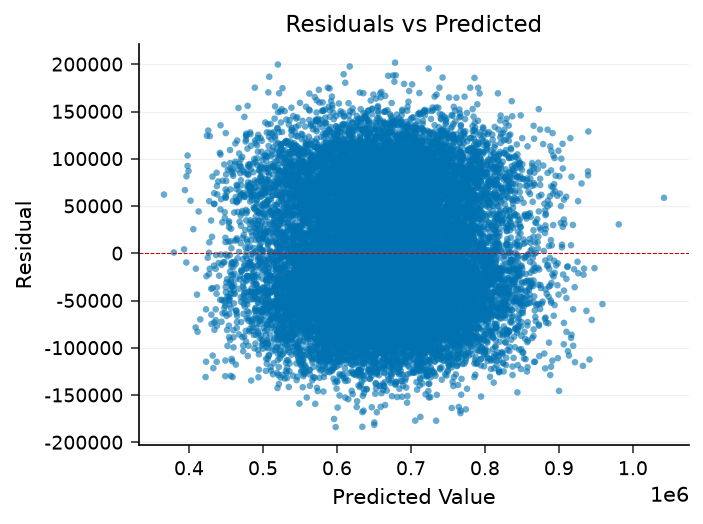

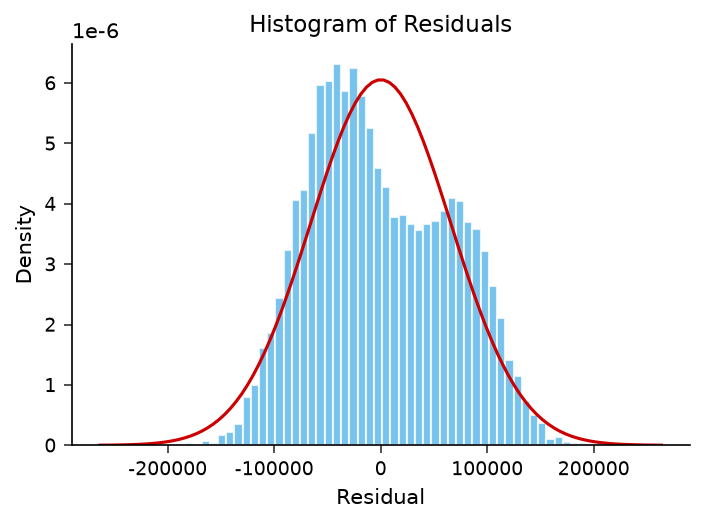

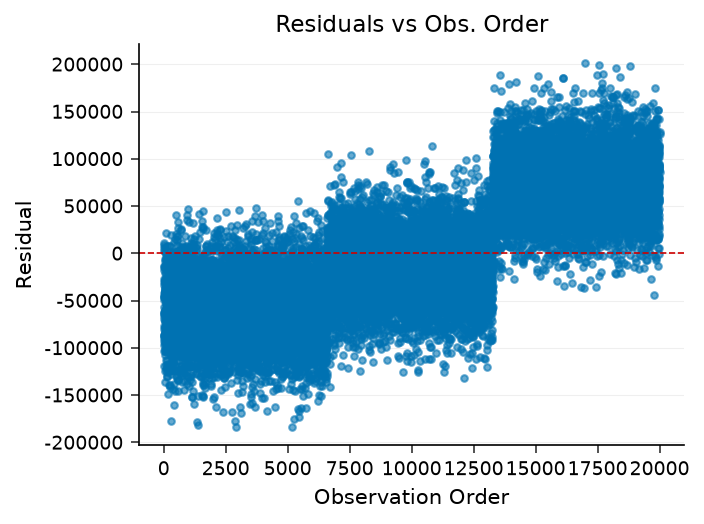

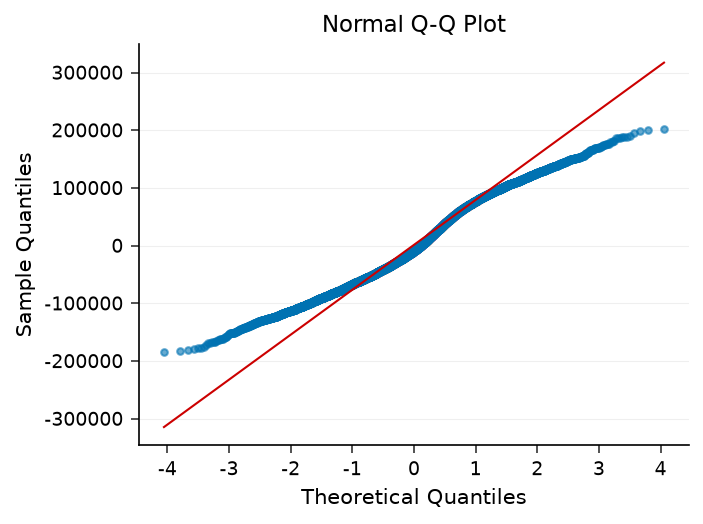

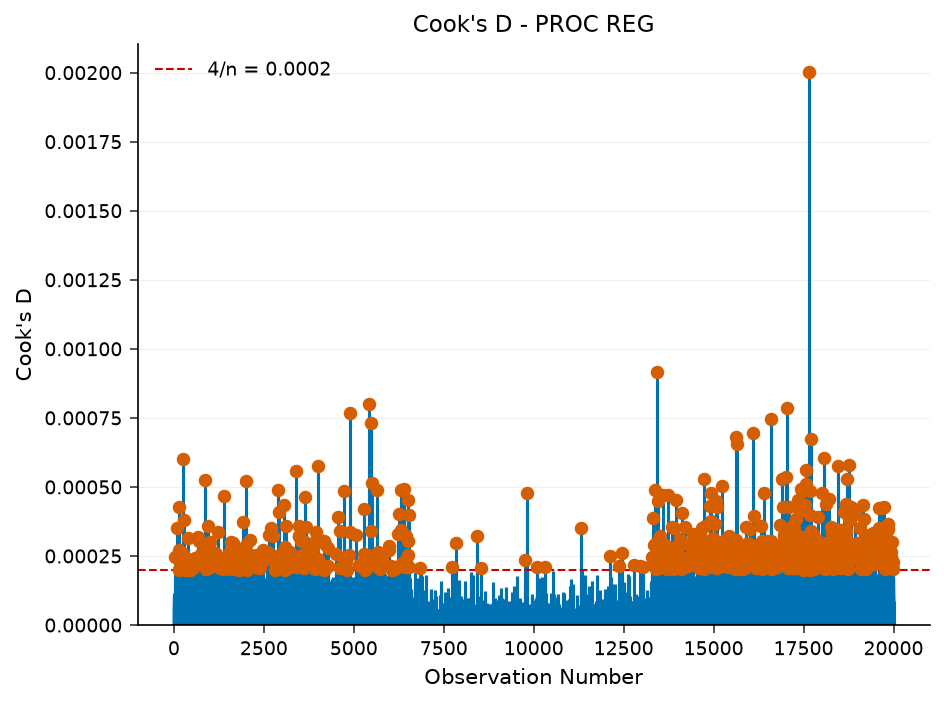

In [5]:
/* --------------------------------------------------------
   Stage 2: refit the stepwise-selected predictors as the
   final hedonic model and request VIF to confirm the
   coefficients are free of multicollinearity. PROC REG
   also emits its standard residual-diagnostic panels.
   -------------------------------------------------------- */
proc reg data=work.property_sales;
    model sale_price = sqft bedrooms bathrooms age_years
                       lot_acres garage_spaces has_pool
                       dist_transit_mi school_rating crime_index
          / vif;
    title 'Final Hedonic Model with Variance Inflation Factors';
run;
quit;


## Stage 3 — High-Influence Properties

To score every property, the final model is refit with `NOPRINT` and an
`OUTPUT` statement that writes predicted values, residuals, Cook's D, and
leverage to `WORK.PROPERTY_PREDICTED` — so the 20,000-row diagnostic table
is captured in a dataset rather than printed.

A standard cutoff flags any property whose Cook's D exceeds `4/n`. The
threshold is computed dynamically from the row count returned by `NOBS=`;
with **n = 20,000** it is **4/20000 = 0.0002**. Because that cutoff flags a
sizeable minority of records, the review list below ranks properties by
Cook's D and shows the **ten most influential** sales — the ones an
appraiser should re-examine first before the model's valuation is trusted.


In [6]:
/* --------------------------------------------------------
   Stage 3: score every property and review the most
   influential records.
   (a) Refit the final model with NOPRINT and write per-
       property predictions, residuals, Cook's D and
       leverage to an output dataset (no 20,000-row
       listing is printed).
   (b) Flag properties whose Cook's D exceeds the standard
       4/n cutoff, computed dynamically from the row count.
   (c) Summarise the fit and list the ten most influential
       sales for manual appraisal review.
   -------------------------------------------------------- */
proc reg data=work.property_sales noprint plots=none;
    model sale_price = sqft bedrooms bathrooms age_years
                       lot_acres garage_spaces has_pool
                       dist_transit_mi school_rating crime_index;
    output out=work.property_predicted
        predicted=pred_price
        residual=resid_price
        cookd=cooksd
        h=leverage;
run;
quit;

/* Flag high-influence properties using the 4/n rule */
data work.property_predicted;
    set work.property_predicted nobs=n_total;
    cookd_threshold = 4 / n_total;
    high_influence = (cooksd > cookd_threshold);
    drop n_total cookd_threshold;
run;

proc means data=work.property_predicted n mean max;
    var sale_price pred_price cooksd leverage;
    title 'Fit Summary Across All Properties';
run;

proc means data=work.property_predicted sum mean;
    var high_influence;
    title 'Share of Properties Above the 4/n Cook''s D Cutoff';
run;

/* Rank by Cook's D and review the ten most influential sales */
proc sort data=work.property_predicted out=work.ranked;
    by descending cooksd;
run;

proc print data=work.ranked(obs=10) noobs;
    var metro_area sqft bedrooms sale_price pred_price
        resid_price cooksd leverage;
    title 'Ten Most Influential Properties (Highest Cook''s D)';
run;


                                           Fit Summary Across All Properties                                            

                                                  The MEANS Procedure

 Variable                  N               Mean             Maximum
 ------------------------------------------------------------------
 sale_price            20000     663507.4791500     1100873.0000000
 Predicted Value       20000     663507.4791499     1042021.0008460
 Cook's D              20000          0.0000499           0.0020030
 Leverage              20000          0.0005500           0.0034180
 ------------------------------------------------------------------

                                   Share of Properties Above the 4/n Cook's D Cutoff                                    

                                                  The MEANS Procedure

 Variable                   Sum           Mean
 ---------------------------------------------
 high_influence     678.0000000      0.0339

NOTE: PROC REG data=work.property_sales

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: Output dataset work.property_predicted written.
NOTE: DATA work.property_predicted


NOTE: Read 20000 rows from work.property_predicted.
NOTE: Wrote work.property_predicted (20000 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.51 seconds
  cpu   0.51 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.property_predicted

NOTE: Read 20000 rows from work.property_predicted.
NOTE: Wrote work.ranked (20000 rows, 18 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=work.ranked

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Export Predicted Valuations

The per-property predictions and diagnostics are written to CSV for downstream
portfolio valuation and appraisal review.


In [7]:
/* --------------------------------------------------------
   Export predicted valuations with diagnostics
   -------------------------------------------------------- */
proc export data=work.property_predicted
    outfile='property_valuations.csv'
    dbms=csv replace;
run;


NOTE: PROC EXPORT data=work.property_predicted outfile=property_valuations.csv

NOTE: Exported 20000 rows to property_valuations.csv.


---


## Interpretation

**Stepwise selection** kept **all ten candidate predictors**: with 20,000
observations every structural and locational feature clears the `SLE=0.10`
entry threshold at `Pr > F < .0001`, and none is later removed. The large
sample gives the procedure ample power to detect each genuine effect built
into the data.

The **final model** explains a meaningful share of price variation:
R-square **0.6224** and adjusted R-square **0.6222** (F = 3295.20,
p < .0001, Root MSE \$65,907). Because the synthetic prices were generated
from a known linear formula, the fitted coefficients can be checked against
the true marginal values — and they line up closely:

- **Living area** adds about **\$135.44 per square foot** (t = 156.76),
  essentially recovering the \$135 used to generate the data.
- Each additional **bathroom** is worth about **\$18,668** (t = 15.47) and
  each **bedroom** about **\$11,185** (t = 12.04).
- A **pool** adds roughly **\$25,114** (t = 20.55) and each **garage space**
  about **\$7,913** (t = 17.58).
- **Lot acreage** adds about **\$45,416 per acre** (t = 29.43) and a one-point
  higher **school rating** about **\$9,311** (t = 36.05).
- The expected penalties also appear: each **year of age** subtracts about
  **\$1,160** (t = -44.32), each **mile** farther from transit about
  **\$5,897** (t = -31.23), and each point of the **crime index** about
  **\$346** (t = -13.30).

**Multicollinearity is mostly negligible, with one expected exception.**
Eight of the ten predictors have a variance inflation factor of about
**1.00**. The two exceptions are **bedrooms** and **bathrooms**, each at
**VIF ≈ 3.36** — unsurprising, since the data generator ties bathroom count
to bedroom count, so the two features carry overlapping information. Both
remain far below the usual VIF = 10 warning level, so the coefficients stay
interpretable; the bedroom and bathroom estimates simply share credit for
the size-of-household effect.

**The residual diagnostics are consistent with the design.** Residuals
versus predicted form a centred, roughly constant-width band, and the
residual histogram is approximately bell-shaped. The residuals-versus-order
panel shows three horizontal bands because the data is sorted by metro area
and the characteristic-only model omits the metro base-price differences
(Metro West homes carry the highest baseline); the Q-Q plot's mild S-shape
reflects that same banding. Metro area is therefore best treated as a
separate market-segmentation dimension (as in the price summary above)
rather than folded into the structural model.

**Influence diagnostics** confirm a stable fit. Across all 20,000 properties
the mean Cook's D is just **0.0000499** (maximum **0.0020**) and mean
leverage is **0.00055** (maximum **0.0034**) — no single sale dominates the
regression. Using the standard **4/n = 0.0002** cutoff, **678 properties
(3.39%)** are flagged as relatively influential. Ranked by Cook's D, the most
influential record is a 1,423-sqft, 3-bedroom Metro West home that sold for
\$664,249 against a predicted \$488,938 — a **+\$175,311** residual. The ten
most influential sales listed above are the over- and under-priced records
to route for manual appraisal review before the model is used for portfolio
valuation.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>